# Прогнозирование почасовой выработки ветроэлектростанции

## Учебное задание по машинному обучению

**Объект моделирования.** Ветроэлектростанция (ВЭС) из 26 ветроагрегатов
Siemens Gamesa единичной мощностью 3.465 МВт. Суммарная установленная мощность
составляет 90.09 МВт. Координаты площадки: широта 46.8268, долгота 38.7179
(побережье Азовского моря). Высота ротора 80 метров.

**Постановка задачи.** По метеорологическим данным для каждого часа требуется
предсказать величину электрической выработки станции в этот час (в мегаваттах).
Это задача регрессии: на входе непрерывные метеопризнаки, на выходе одно
непрерывное число.

**Что вы научитесь делать в этом ноутбуке:**

1. Загружать и проверять структуру табличных данных временного ряда.
2. Конструировать признаки (feature engineering), исходя из физики работы
   ветрогенератора, а не вслепую.
3. Корректно оценивать качество модели на отложенной выборке (holdout),
   избегая утечки данных из будущего в прошлое.
4. Обучать градиентный бустинг (LightGBM) и интерпретировать его метрики.
5. Формировать файл прогноза для автоматической проверки.
6. Понимать принципиальную разницу между восстановлением выработки по
   фактической погоде и прогнозом выработки по прогнозу погоды.

Перед началом работы изучите сопроводительный документ с заданием. Ячейки
ниже выполняйте последовательно сверху вниз.


## Раздел 0. Установка библиотек

В среде Google Colab большинство библиотек уже установлены. Отдельно ставим
LightGBM — реализацию градиентного бустинга, которая будет основной моделью.
Если ячейка сообщит, что пакет уже присутствует, это нормально.


In [ ]:
# Установка LightGBM. Флаг -q уменьшает количество служебных сообщений.
!pip install -q lightgbm

import sys
print("Python:", sys.version.split()[0])


Python: 3.14.3


## Раздел 1. Импорт библиотек и базовые настройки

Импортируем рабочие библиотеки одним блоком, чтобы все зависимости были видны
сразу. Назначение каждой:

- **numpy** — численные операции с массивами.
- **pandas** — работа с таблицами (DataFrame).
- **lightgbm** — модель градиентного бустинга над деревьями решений.
- **matplotlib** — построение графиков.
- **scikit-learn** — функции расчёта метрик качества.

Параметр `RANDOM_SEED` фиксирует генератор случайных чисел. Это требование
воспроизводимости: при повторном запуске результат не должен меняться.


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

# --- Глобальные константы задачи ---------------------------------------------
CAPACITY   = 90.09          # установленная мощность ВЭС, МВт (физический потолок)
N_TURBINES = 26             # число ветроагрегатов
LATITUDE   = 46.8268455973  # широта площадки
LONGITUDE  = 38.7179393185  # долгота площадки
ROTOR_H    = 80             # высота ротора, м

# Имена ключевых столбцов в исходных файлах
TARGET = "Выработка. Результирующий расчет"   # целевая переменная
DT_COL = "METEOFORECASTHOUR_OPENM_Datetime"   # отметка времени (час)

# Базовый seed и набор seed-ов для усреднения нескольких моделей
RANDOM_SEED = 42
SEEDS = [42, 123, 777, 2024, 9001]

print("Установленная мощность:", CAPACITY, "МВт")
print("Число турбин:", N_TURBINES)
print("Высота ротора:", ROTOR_H, "м")


Установленная мощность: 90.09 МВт
Число турбин: 26
Высота ротора: 80 м


## Раздел 2. Загрузка данных

Нужны два файла:

- **train_dataset.csv** — обучающая выборка. Содержит метеопризнаки и
  фактическую выработку за прошедший период (несколько лет почасовых данных).
- **valid_features.csv** — проверочная выборка. Содержит только метеопризнаки
  за прогнозируемый период. Столбца с выработкой здесь нет — именно его значения
  нужно предсказать.

В Google Colab загрузите оба файла через панель «Файлы» слева (значок папки),
либо выполните ячейку с `files.upload()` ниже и выберите файлы вручную.


In [ ]:
# Вариант загрузки через диалоговое окно (раскомментируйте при необходимости).
# from google.colab import files
# uploaded = files.upload()   # выберите train_dataset.csv и valid_features.csv

TRAIN_PATH = "dataset/train_dataset.csv"
VALID_PATH = "dataset/valid_features.csv"

train = pd.read_csv(TRAIN_PATH)
valid = pd.read_csv(VALID_PATH)

# Преобразуем столбец времени из текста в формат даты-времени.
train[DT_COL] = pd.to_datetime(train[DT_COL])
valid[DT_COL] = pd.to_datetime(valid[DT_COL])

# Запоминаем исходный порядок строк проверочной выборки.
# Итоговый файл прогноза должен иметь строки ровно в этом порядке.
valid_order = valid[DT_COL].copy()

# Сортируем обучающую выборку по времени. Для временного ряда это обязательно:
# операции со скользящими окнами и корректное разбиение требуют хронологии.
train = train.sort_values(DT_COL).reset_index(drop=True)

print("Обучающая выборка:", train.shape)
print("  период:", train[DT_COL].min(), "...", train[DT_COL].max())
print("Проверочная выборка:", valid.shape)
print("  период:", valid[DT_COL].min(), "...", valid[DT_COL].max())


Обучающая выборка: (32434, 21)
  период: 2022-01-01 00:00:00 ... 2025-12-31 23:00:00
Проверочная выборка: (2126, 20)
  период: 2026-01-01 00:00:00 ... 2026-03-31 23:00:00


## Раздел 3. Первичный осмотр данных

Прежде чем строить модель, инженер обязан понять данные: какие столбцы есть,
есть ли пропуски, как распределена целевая переменная. Пропущенные результаты
этого шага — частая причина скрытых ошибок в дальнейшем.


In [ ]:
# Список столбцов и их типы.
print("Столбцы обучающей выборки:")
for c in train.columns:
    print("  -", c)

print("\nПропуски по столбцам (только там, где они есть):")
na = train.isnull().sum()
print(na[na > 0] if (na > 0).any() else "  пропусков нет")


Столбцы обучающей выборки:
  - METEOFORECASTHOUR_OPENM_Datetime
  - month
  - hour_of_day
  - Выработка. Результирующий расчет
  - wind_speed_10m
  - wind_speed_80m
  - wind_speed_120m
  - wind_speed_180m
  - wind_direction_10m
  - wind_direction_80m
  - wind_direction_120m
  - wind_direction_180m
  - wind_gusts_10m
  - temperature_80m
  - temperature_120m
  - pressure_msl
  - rain
  - showers
  - snowfall
  - cloud_cover_low
  - Кол-во_ВЭУ_в_ремонте

Пропуски по столбцам (только там, где они есть):
wind_speed_180m        6836
wind_direction_180m    6836
dtype: int64


Статистика выработки, МВт:
count    32434.000000
mean        33.005746
std         26.121408
min          0.001000
25%          8.838750
50%         27.124500
75%         56.943250
max         87.475000
Name: Выработка. Результирующий расчет, dtype: float64


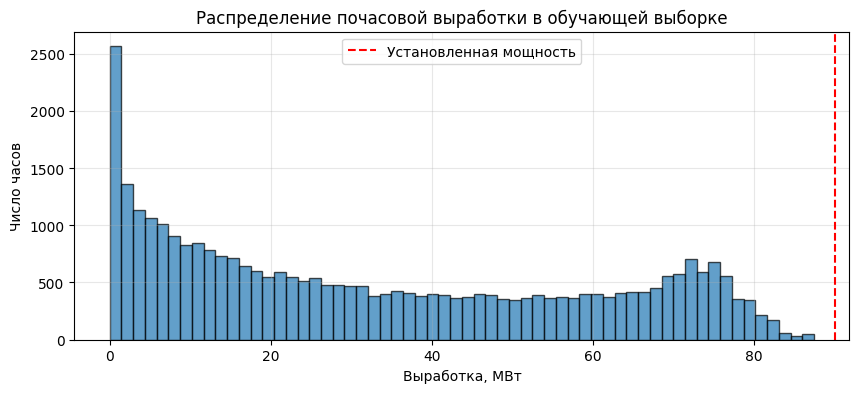

In [ ]:
# Статистика целевой переменной (выработки).
print("Статистика выработки, МВт:")
print(train[TARGET].describe())

# Гистограмма распределения выработки.
plt.figure(figsize=(10, 4))
plt.hist(train[TARGET], bins=60, color="#1f77b4", edgecolor="black", alpha=0.7)
plt.axvline(CAPACITY, color="red", linestyle="--", label="Установленная мощность")
plt.xlabel("Выработка, МВт")
plt.ylabel("Число часов")
plt.title("Распределение почасовой выработки в обучающей выборке")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Что важно заметить на гистограмме.** Распределение выработки сильно
смещено к нулю: ВЭС часто работает на малой мощности (слабый ветер) и редко
выходит на номинал. Это типично для ветрогенерации и объясняет, почему средний
коэффициент использования установленной мощности (КИУМ) у ВЭС обычно
находится в диапазоне 25-45%.


## Раздел 4. Анализ зависимости выработки от ветра

Физическая основа задачи: мощность ветрового потока пропорциональна **кубу**
скорости ветра. Реальный ветрогенератор имеет характеристическую кривую
мощности (power curve) со следующими участками:

- **Ниже скорости включения** (примерно 3 м/с) — турбина не вращается,
  выработка близка к нулю.
- **Рабочий участок** — выработка растёт примерно как куб скорости ветра.
- **Выход на номинал** (около 12-13 м/с) — выработка ограничена номинальной
  мощностью генератора и далее не растёт.
- **Скорость отключения** (около 25 м/с) — турбина останавливается ради
  защиты от разрушения.

Построим эмпирическую кривую мощности по обучающим данным. Используем ветер на
высоте 80 метров, поскольку это высота ротора.


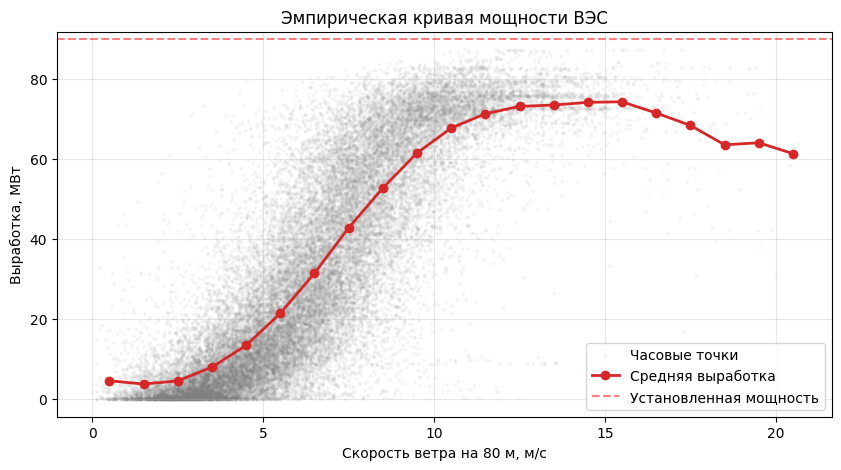

In [ ]:
# Эмпирическая кривая мощности: средняя выработка для каждого диапазона скорости.
ws = train["wind_speed_80m"]
bins = np.arange(0, 26, 1.0)
labels = (bins[:-1] + bins[1:]) / 2
train["_ws_bin"] = pd.cut(ws, bins=bins, labels=labels)
curve = train.groupby("_ws_bin")[TARGET].mean()

plt.figure(figsize=(10, 5))
plt.scatter(ws, train[TARGET], s=3, alpha=0.05, color="gray", label="Часовые точки")
plt.plot(curve.index.astype(float), curve.values, "o-", color="#d62728",
         linewidth=2, label="Средняя выработка")
plt.axhline(CAPACITY, color="red", linestyle="--", alpha=0.5,
            label="Установленная мощность")
plt.xlabel("Скорость ветра на 80 м, м/с")
plt.ylabel("Выработка, МВт")
plt.title("Эмпирическая кривая мощности ВЭС")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

train.drop(columns=["_ws_bin"], inplace=True)


**Вывод для конструирования признаков.** Зависимость выработки от ветра
существенно нелинейная (S-образная). Линейная модель такую форму не опишет.
Поэтому мы выбираем градиентный бустинг над деревьями: он способен описывать
произвольные нелинейные зависимости. Кроме того, мы добавим скорость ветра во
второй и третьей степени, чтобы дать модели подсказку о физике процесса.


## Раздел 5. Конструирование признаков (feature engineering)

Это центральный этап. Качество модели определяется в первую очередь качеством
признаков, а не выбором алгоритма. Создадим три группы признаков.

**Группа 1. Календарные циклические признаки.** Время суток и время года влияют
на ветер. Час 23 и час 0 соседние, но по числовому значению далеки. Чтобы
модель видела цикличность, кодируем час, месяц и день года парой синус-косинус.
Тогда соседние моменты времени оказываются близки и в признаковом пространстве.

**Группа 2. Направление ветра.** Это важный технический момент. В исходных
данных направление ветра хранится в нестандартном масштабе: значения лежат в
диапазоне примерно от 0.001 до 0.360. Фактически это **градусы, делённые на
1000** (то есть 0.275 соответствует 275 градусам). Чтобы корректно перевести
направление в признаки, мы сначала восстанавливаем градусы (умножая на 1000),
затем кодируем угол парой синус-косинус. Так направление 359 и 1 градус
оказываются рядом, как и должно быть для угла.

**Группа 3. Физические производные ветра.** Скорость ветра в квадрате и в кубе
(связь с мощностью потока), разность скоростей на разных высотах (сдвиг ветра),
отношение порывов к средней скорости (турбулентность), а также доля работающих
турбин с учётом числа агрегатов в ремонте.


In [ ]:
def add_features(df):
    """Добавляет признаки в таблицу. Возвращает новую таблицу (исходную не меняет)."""
    df = df.copy()
    dt = df[DT_COL]

    # --- Группа 1: календарные циклические признаки ---
    df["dayofyear"] = dt.dt.dayofyear
    df["dayofweek"] = dt.dt.dayofweek
    df["week"]      = dt.dt.isocalendar().week.astype(int)

    df["hour_sin"]  = np.sin(2 * np.pi * df["hour_of_day"] / 24)
    df["hour_cos"]  = np.cos(2 * np.pi * df["hour_of_day"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)
    df["doy_sin"]   = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["doy_cos"]   = np.cos(2 * np.pi * df["dayofyear"] / 365)

    # --- Группа 2: направление ветра ---
    # В исходных данных направление хранится как градусы / 1000.
    # Восстанавливаем градусы и кодируем угол синус-косинусом.
    # Приведение к числовому типу обязательно: данные из внешнего API
    # могут прийти как тип object, и тогда numpy-функции откажут.
    for col in ["wind_direction_10m", "wind_direction_80m",
                "wind_direction_120m", "wind_direction_180m"]:
        deg = pd.to_numeric(df[col], errors="coerce") * 1000.0   # вернуть градусы 0..360
        df[col + "_sin"] = np.sin(np.deg2rad(deg))
        df[col + "_cos"] = np.cos(np.deg2rad(deg))

    # --- Группа 3: физические производные ---
    df["wind_speed_80m_sq"]    = df["wind_speed_80m"] ** 2     # ~ давление потока
    df["wind_speed_80m_cube"]  = df["wind_speed_80m"] ** 3     # ~ мощность потока
    df["wind_speed_120m_cube"] = df["wind_speed_120m"] ** 3
    df["wind_shear"]           = df["wind_speed_120m"] - df["wind_speed_10m"]  # сдвиг ветра
    df["gust_ratio"]           = df["wind_gusts_10m"] / (df["wind_speed_10m"] + 0.1)  # турбулентность
    df["wind_avg"]             = df[["wind_speed_80m", "wind_speed_120m"]].mean(axis=1)

    # Доступность парка турбин с учётом ремонта
    df["turbines_available"] = N_TURBINES - df["Кол-во_ВЭУ_в_ремонте"]
    df["available_ratio"]    = df["turbines_available"] / N_TURBINES
    return df


def fill_missing_180m(df):
    """Заполняет пропуски в данных на высоте 180 м значениями со 120 м.

    На высоте 180 м часть наблюдений отсутствует. Поскольку 120 м физически
    ближайшая доступная высота, используем её как разумное приближение.
    """
    df = df.copy()
    df["wind_speed_180m"]         = df["wind_speed_180m"].fillna(df["wind_speed_120m"])
    df["wind_direction_180m"]     = df["wind_direction_180m"].fillna(df["wind_direction_120m"])
    df["wind_direction_180m_sin"] = df["wind_direction_180m_sin"].fillna(df["wind_direction_120m_sin"])
    df["wind_direction_180m_cos"] = df["wind_direction_180m_cos"].fillna(df["wind_direction_120m_cos"])
    return df


# Применяем преобразования к обеим выборкам одинаково.
train_f = fill_missing_180m(add_features(train))
valid_f = fill_missing_180m(add_features(valid))

# Список признаков: все столбцы, кроме целевой переменной и отметки времени.
FEATURES = [c for c in train_f.columns if c not in [TARGET, DT_COL]]
print("Количество признаков:", len(FEATURES))
print("\nСписок признаков:")
for c in FEATURES:
    print("  -", c)


Количество признаков: 44

Список признаков:
  - month
  - hour_of_day
  - wind_speed_10m
  - wind_speed_80m
  - wind_speed_120m
  - wind_speed_180m
  - wind_direction_10m
  - wind_direction_80m
  - wind_direction_120m
  - wind_direction_180m
  - wind_gusts_10m
  - temperature_80m
  - temperature_120m
  - pressure_msl
  - rain
  - showers
  - snowfall
  - cloud_cover_low
  - Кол-во_ВЭУ_в_ремонте
  - dayofyear
  - dayofweek
  - week
  - hour_sin
  - hour_cos
  - month_sin
  - month_cos
  - doy_sin
  - doy_cos
  - wind_direction_10m_sin
  - wind_direction_10m_cos
  - wind_direction_80m_sin
  - wind_direction_80m_cos
  - wind_direction_120m_sin
  - wind_direction_120m_cos
  - wind_direction_180m_sin
  - wind_direction_180m_cos
  - wind_speed_80m_sq
  - wind_speed_80m_cube
  - wind_speed_120m_cube
  - wind_shear
  - gust_ratio
  - wind_avg
  - turbines_available
  - available_ratio


## Раздел 6. Подготовка матриц для обучения

Модель принимает на вход числовую матрицу признаков X и вектор ответов y.
Сформируем их из подготовленных таблиц.


In [ ]:
X       = train_f[FEATURES].values   # матрица признаков обучающей выборки
y       = train_f[TARGET].values     # вектор фактической выработки
X_valid = valid_f[FEATURES].values   # матрица признаков проверочной выборки

print("Размер X (обучение):", X.shape)
print("Размер y (обучение):", y.shape)
print("Размер X (проверка):", X_valid.shape)


Размер X (обучение): (32434, 44)
Размер y (обучение): (32434,)
Размер X (проверка): (2126, 44)


## Раздел 7. Отложенная проверка (holdout) и почему она именно такая

Чтобы честно оценить качество модели до отправки на проверку, отложим часть
обучающих данных и проверим модель на ней.

**Ключевое решение: в качестве отложенной выборки берём январь-март 2025 года.**
Причины:

1. Проверочный период задачи — это первый квартал 2026 года. Чтобы оценка была
   репрезентативной, отложенная выборка должна быть из той же части года
   (та же сезонность ветров).
2. Нельзя выбирать отложенные часы случайно по всему ряду. Соседние часы сильно
   коррелированы, и случайное разбиение привело бы к утечке информации: модель
   фактически подсматривала бы соседние часы. Блочное разбиение по целому
   кварталу исключает эту утечку.

Это прямое следствие требования воспроизводимости и честности оценки.


In [ ]:
# Маска отложенной выборки: январь, февраль, март 2025 года.
holdout_mask = (train_f[DT_COL] >= "2025-01-01") & (train_f[DT_COL] < "2025-04-01")

X_tr, X_ho = X[~holdout_mask], X[holdout_mask]   # обучающая и отложенная части
y_tr, y_ho = y[~holdout_mask], y[holdout_mask]

print("Часов для обучения:", len(y_tr))
print("Часов в отложенной выборке (Q1 2025):", len(y_ho))


Часов для обучения: 30418
Часов в отложенной выборке (Q1 2025): 2016


## Раздел 8. Обучение модели и усреднение по нескольким запускам

Используем LightGBM — градиентный бустинг над деревьями решений. Кратко о
смысле основных гиперпараметров:

- **n_estimators** — максимальное число деревьев. Реальное число определит
  ранняя остановка.
- **learning_rate** — скорость обучения. Меньше значение — точнее, но нужно
  больше деревьев.
- **num_leaves** — сложность одного дерева (число листьев).
- **subsample, colsample_bytree** — доля строк и столбцов на каждое дерево.
  Вносят случайность и снижают переобучение.
- **reg_alpha, reg_lambda** — регуляризация, штраф за сложность.
- **early_stopping** — прекратить добавлять деревья, когда ошибка на отложенной
  выборке перестала улучшаться.

**Зачем несколько seed-ов.** Бустинг содержит случайность (подвыборки строк и
столбцов). Обучив пять моделей с разными значениями seed и усреднив их прогнозы,
мы уменьшаем разброс и получаем чуть более устойчивый результат. Этот приём
называется усреднением по ансамблю (bagging по seed).


In [ ]:
def make_model(seed, n_estimators=3000):
    """Создаёт регрессор LightGBM с фиксированными гиперпараметрами."""
    return lgb.LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=0.025,
        num_leaves=63,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )


holdout_preds = []   # прогнозы каждой модели на отложенной выборке
best_iters    = []   # оптимальное число деревьев по ранней остановке

for i, seed in enumerate(SEEDS, 1):
    model = make_model(seed)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_ho, y_ho)],
        callbacks=[lgb.early_stopping(75, verbose=False)],
    )
    # Прогноз обрезаем в физически допустимый диапазон [0, установленная мощность].
    pred = np.clip(model.predict(X_ho), 0, CAPACITY)
    holdout_preds.append(pred)
    best_iters.append(model.best_iteration_ or 1500)
    print(f"[{i}/{len(SEEDS)}] seed={seed:>4}  лучшее число деревьев={model.best_iteration_}")

# Итоговый прогноз ансамбля — среднее по пяти моделям.
ho_pred = np.mean(holdout_preds, axis=0)
print("\nОбучение на отложенной выборке завершено.")


[1/5] seed=  42  лучшее число деревьев=209
[2/5] seed= 123  лучшее число деревьев=275
[3/5] seed= 777  лучшее число деревьев=328
[4/5] seed=2024  лучшее число деревьев=223
[5/5] seed=9001  лучшее число деревьев=273

Обучение на отложенной выборке завершено.


## Раздел 9. Метрики качества и их интерпретация

Оценим прогноз на отложенной выборке. Используем метрики:

- **MAE** (средняя абсолютная ошибка) — на сколько мегаватт в среднем ошибается
  модель. Это основная метрика конкурса. Удобно выражать её в процентах от
  установленной мощности.
- **RMSE** (корень из средней квадратичной ошибки) — сильнее штрафует крупные
  промахи.
- **R2** (коэффициент детерминации) — доля дисперсии выработки, объяснённая
  моделью. Значение 1 — идеал, 0 — модель не лучше среднего.
- **Смещение (bias)** — систематическая переоценка или недооценка.


In [ ]:
mae   = mean_absolute_error(y_ho, ho_pred)
rmse  = np.sqrt(mean_squared_error(y_ho, ho_pred))
r2    = r2_score(y_ho, ho_pred)
bias  = np.mean(ho_pred - y_ho)

print("Метрики на отложенной выборке (Q1 2025):")
print(f"  MAE  = {mae:6.3f} МВт   ({100 * mae  / CAPACITY:5.2f} % от установленной мощности)")
print(f"  RMSE = {rmse:6.3f} МВт   ({100 * rmse / CAPACITY:5.2f} % от установленной мощности)")
print(f"  R2   = {r2:6.4f}")
print(f"  Смещение = {bias:+6.3f} МВт")


Метрики на отложенной выборке (Q1 2025):
  MAE  =  8.129 МВт   ( 9.02 % от установленной мощности)
  RMSE = 11.250 МВт   (12.49 % от установленной мощности)
  R2   = 0.8157
  Смещение = +0.665 МВт


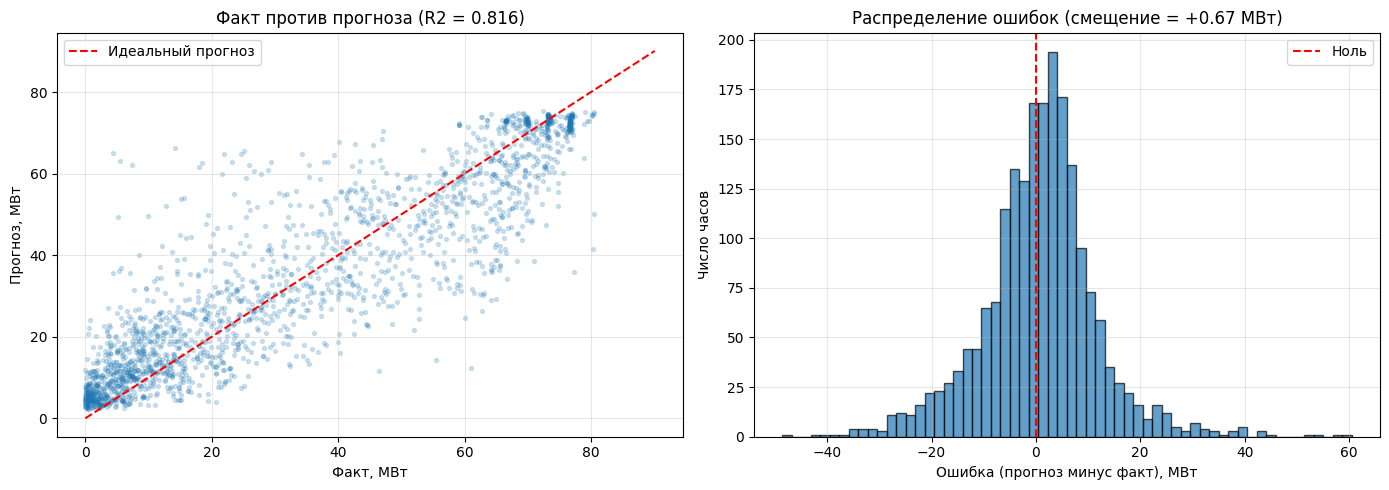

In [ ]:
# Диагностические графики качества модели.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: факт против прогноза. Идеальная модель легла бы на красную линию.
ax = axes[0]
ax.scatter(y_ho, ho_pred, alpha=0.2, s=8, color="#1f77b4")
ax.plot([0, CAPACITY], [0, CAPACITY], "r--", label="Идеальный прогноз")
ax.set_xlabel("Факт, МВт")
ax.set_ylabel("Прогноз, МВт")
ax.set_title(f"Факт против прогноза (R2 = {r2:.3f})")
ax.legend(); ax.grid(alpha=0.3)

# График 2: распределение ошибок. В идеале симметрично вокруг нуля.
ax = axes[1]
errors = ho_pred - y_ho
ax.hist(errors, bins=60, color="#1f77b4", alpha=0.7, edgecolor="black")
ax.axvline(0, color="red", linestyle="--", label="Ноль")
ax.set_xlabel("Ошибка (прогноз минус факт), МВт")
ax.set_ylabel("Число часов")
ax.set_title(f"Распределение ошибок (смещение = {bias:+.2f} МВт)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


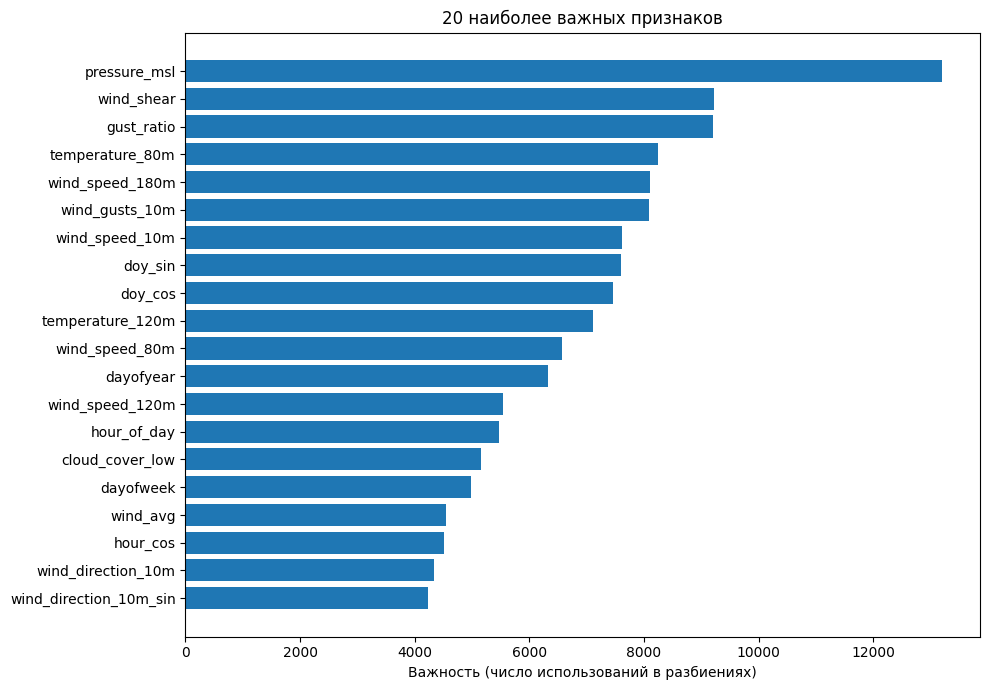

In [ ]:
# Важность признаков: какие входы модель использует активнее всего.
importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": make_model(RANDOM_SEED).fit(X_tr, y_tr).feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 7))
top = importance.head(20).iloc[::-1]
plt.barh(top["feature"], top["importance"], color="#1f77b4")
plt.xlabel("Важность (число использований в разбиениях)")
plt.title("20 наиболее важных признаков")
plt.tight_layout()
plt.show()


**Как читать результаты.** Значение MAE около 8 МВт (примерно 9% от
установленной мощности) — разумный ориентир для этой задачи. В числе самых
важных признаков почти всегда оказываются скорость ветра на высоте ротора и её
степени, а также сезонные признаки. Если в важных признаках доминирует что-то
неожиданное, это повод перепроверить feature engineering.


## Раздел 10. Обучение финальной модели на всех данных

Отложенная выборка нужна была только для честной оценки. Для итогового прогноза
обучаем модели заново уже на **всех** обучающих данных, чтобы использовать
максимум информации. Число деревьев берём по медиане ранней остановки,
полученной на этапе проверки, с небольшим запасом (данных стало больше).


In [ ]:
n_iter = int(np.median(best_iters) * 1.1)   # запас 10%, т.к. данных теперь больше
print("Число деревьев для финальных моделей:", n_iter)

final_models = []
valid_preds  = []

for i, seed in enumerate(SEEDS, 1):
    model = make_model(seed, n_estimators=n_iter)
    model.fit(X, y)                       # обучение на ВСЕХ данных, без ранней остановки
    final_models.append(model)
    valid_preds.append(np.clip(model.predict(X_valid), 0, CAPACITY))
    print(f"[{i}/{len(SEEDS)}] финальная модель seed={seed} обучена")

# Усредняем прогнозы пяти моделей.
final_pred = np.mean(valid_preds, axis=0)
print("\nФинальный прогноз получен.")


Число деревьев для финальных моделей: 300
[1/5] финальная модель seed=42 обучена
[2/5] финальная модель seed=123 обучена
[3/5] финальная модель seed=777 обучена
[4/5] финальная модель seed=2024 обучена
[5/5] финальная модель seed=9001 обучена

Финальный прогноз получен.


## Раздел 11. Постобработка прогноза с учётом физики

Чистый прогноз модели полезно скорректировать по физическим ограничениям:

1. Если все турбины в ремонте, выработка равна нулю.
2. Выработка не может превышать мощность работающих турбин (доля доступного
   парка, умноженная на установленную мощность).
3. Выработка не может быть отрицательной или больше установленной мощности.

Эти ограничения не дают модели выдавать физически невозможные значения.


In [ ]:
# Ограничение 1: все турбины в ремонте -> выработка ноль.
zero_mask = valid_f["turbines_available"].values <= 0
final_pred[zero_mask] = 0.0

# Ограничение 2: не больше мощности доступного парка турбин.
final_pred = np.minimum(final_pred,
                        CAPACITY * valid_f["available_ratio"].values + 1e-3)

# Ограничение 3: физический диапазон [0, установленная мощность].
final_pred = np.clip(final_pred, 0, CAPACITY)

print("Статистика итогового прогноза, МВт:")
print(f"  минимум:  {final_pred.min():6.2f}")
print(f"  среднее:  {final_pred.mean():6.2f}")
print(f"  максимум: {final_pred.max():6.2f}")
print(f"  средний КИУМ: {100 * final_pred.mean() / CAPACITY:.1f} %")


Статистика итогового прогноза, МВт:
  минимум:    1.33
  среднее:   38.15
  максимум:  77.16
  средний КИУМ: 42.3 %


## Раздел 12. Формирование файла прогноза

Согласно требованиям задания итоговый файл — это CSV с одним столбцом почасовых
значений выработки. Число строк должно совпадать с числом строк в
valid_features.csv, а порядок строк — соответствовать исходному порядку файла.


In [ ]:
# Восстанавливаем исходный порядок строк проверочной выборки.
result = (
    pd.DataFrame({DT_COL: valid_f[DT_COL].values, TARGET: final_pred})
    .set_index(DT_COL)
    .loc[valid_order]
    .reset_index()
)

# Сохраняем только столбец с прогнозом (формат как у исходных данных).
result[[TARGET]].to_csv("predictions.csv", index=False)

print("Файл predictions.csv сохранён.")
print("Строк в файле:", len(result), "(ожидается", len(valid), ")")
assert len(result) == len(valid), "Число строк не совпадает с проверочной выборкой!"
print("Проверка числа строк пройдена.")

# В Google Colab файл можно скачать так:
# from google.colab import files
# files.download("predictions.csv")


Файл predictions.csv сохранён.
Строк в файле: 2126 (ожидается 2126 )
Проверка числа строк пройдена.


## Раздел 13. Прогноз на конкретные сутки и важное методическое замечание

Задание также требует прогноз выработки на 18 мая 2026 года. Здесь возникает
методически важный момент, который должен понимать каждый инженер.

**Две принципиально разные задачи.**

1. **Восстановление выработки по фактической погоде.** Если взять уже
   состоявшиеся (наблюдённые) метеоданные за прошедший день и по ним
   предсказать выработку, мы решаем задачу интерполяции. Ошибка здесь мала,
   потому что вход почти не содержит неопределённости.

2. **Прогноз выработки по прогнозу погоды.** В реальной диспетчерской работе на
   завтрашний день известен только прогноз погоды, у которого есть собственная
   ошибка. Эта ошибка переносится на выработку и складывается с ошибкой модели.
   Поэтому реальный суточный прогноз всегда менее точен.

Ниже мы получаем метеоданные на 18 мая 2026 года с сервиса Open-Meteo и считаем
выработку. Поскольку сервис отдаёт направление ветра в стандартных градусах
(0..360), а наша функция признаков ожидает формат «градусы / 1000», мы приводим
данные к нужному масштабу делением на 1000 перед подачей в модель.


In [ ]:
import requests

def fetch_weather(date_str, source="forecast"):
    """Загружает почасовую погоду на сутки date_str для координат ВЭС.

    source="forecast"      — свежий прогноз на ближайшее будущее (будущие даты).
    source="archive"       — архив реально наблюдавшейся погоды (прошлое).
    source="past_forecast" — архив ПРОГНОЗОВ: что предсказывалось заранее на ту
                             уже прошедшую дату (historical-forecast API).

    Важно про высоты ветра:
      - прогнозные модели (forecast / past_forecast) дают ветер на всех высотах;
      - архив наблюдений (archive, ERA5) обычно содержит ветер ТОЛЬКО на 10 м.
    Чтобы выработка считалась корректно во всех режимах, недостающие высоты
    восстанавливаются из ветра на 10 м по степенному профилю пограничного слоя:
        v(h) = v10 * (h / 10) ** alpha,   alpha ~ 0.14 (нейтральная атмосфера).
    Так модель всегда получает непустой ветер на 80/120/180 м.
    """
    if source == "archive":
        url = "https://archive-api.open-meteo.com/v1/archive"
    elif source == "past_forecast":
        url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
    else:
        url = "https://api.open-meteo.com/v1/forecast"

    hourly_vars = [
        "wind_speed_10m", "wind_speed_80m", "wind_speed_120m", "wind_speed_180m",
        "wind_direction_10m", "wind_direction_80m",
        "wind_direction_120m", "wind_direction_180m",
        "wind_gusts_10m", "temperature_80m", "temperature_120m",
        "pressure_msl", "rain", "showers", "snowfall", "cloud_cover_low",
    ]
    params = {
        "latitude": LATITUDE,
        "longitude": LONGITUDE,
        "hourly": ",".join(hourly_vars),
        "start_date": date_str,
        "end_date": date_str,
        "timezone": "UTC",
        "wind_speed_unit": "ms",   # метры в секунду, как в обучающих данных
    }
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    h = response.json()["hourly"]

    # Берём только реально пришедшие переменные (набор у API различается).
    df = pd.DataFrame({DT_COL: pd.to_datetime(h["time"])})
    for v in hourly_vars:
        df[v] = pd.to_numeric(h[v], errors="coerce") if v in h else np.nan

    # --- Восстановление недостающих высот ветра из 10 м ---
    # Если на высоте нет данных (типично для архива наблюдений), считаем её
    # по степенному профилю из ветра на 10 м.
    ALPHA = 0.14
    for hgt in [80, 120, 180]:
        col = f"wind_speed_{hgt}m"
        factor = (hgt / 10.0) ** ALPHA
        approx = df["wind_speed_10m"] * factor
        df[col] = df[col].fillna(approx)
    # Направление на высотах: если нет — берём с 10 м (грубое, но приемлемое допущение)
    for hgt in [80, 120, 180]:
        col = f"wind_direction_{hgt}m"
        df[col] = df[col].fillna(df["wind_direction_10m"])
    # Температуры на высотах: если нет — оставляем как есть (add_features справится),
    # но подстрахуемся ниже общим fillna в predict_day.

    df["month"]       = df[DT_COL].dt.month
    df["hour_of_day"] = df[DT_COL].dt.hour

    # Приведение направления к формату обучающих данных: градусы -> градусы/1000.
    for col in ["wind_direction_10m", "wind_direction_80m",
                "wind_direction_120m", "wind_direction_180m"]:
        df[col] = df[col] / 1000.0

    # Среднее число турбин в ремонте в мае по обучающим данным.
    may_repair = train.loc[train["month"] == 5, "Кол-во_ВЭУ_в_ремонте"].mean()
    df["Кол-во_ВЭУ_в_ремонте"] = may_repair

    return df


def predict_day(day_df):
    """Считает почасовую выработку для таблицы погоды на сутки."""
    day_f = fill_missing_180m(add_features(day_df))
    # Подстраховка: если в данных из API остались пропуски в каком-либо
    # признаке, заполняем их нулём, иначе модель выдаст ошибку.
    X_day = day_f[FEATURES].fillna(0).values
    preds = [np.clip(m.predict(X_day), 0, CAPACITY) for m in final_models]
    p = np.mean(preds, axis=0)
    p = np.minimum(p, CAPACITY * day_f["available_ratio"].values + 1e-3)
    return np.clip(p, 0, CAPACITY)


In [ ]:
FORECAST_DATE = "2026-05-18"

# Загружаем фактическую (архивную) погоду за прошедший день.
# Если день ещё не наступил, замените source на "forecast".
try:
    day_df = fetch_weather(FORECAST_DATE, source="archive")
    source_used = "архив (фактическая погода)"
except Exception as e:
    print("Архив недоступен, пробуем обычный прогноз. Причина:", e)
    day_df = fetch_weather(FORECAST_DATE, source="forecast")
    source_used = "прогноз погоды"

day_pred = predict_day(day_df)

print(f"Источник метеоданных: {source_used}")
print(f"Скорость ветра на 80 м: от {day_df['wind_speed_80m'].min():.1f} "
      f"до {day_df['wind_speed_80m'].max():.1f} м/с")
print(f"\nПочасовой прогноз выработки на {FORECAST_DATE}:")
for t, p in zip(day_df[DT_COL], day_pred):
    print(f"  {t.strftime('%H:%M')}  {p:6.2f} МВт")

total = day_pred.sum()
print(f"\nСуточная выработка: {total:.1f} МВт*ч")
print(f"Средняя мощность:   {day_pred.mean():.2f} МВт")
print(f"КИУМ за сутки:      {100 * day_pred.mean() / CAPACITY:.1f} %")


Источник метеоданных: архив (фактическая погода)
Скорость ветра на 80 м: от 2.2 до 5.8 м/с

Почасовой прогноз выработки на 2026-05-18:
  00:00    7.06 МВт
  01:00   12.60 МВт
  02:00   16.43 МВт
  03:00   14.40 МВт
  04:00   13.53 МВт
  05:00   10.46 МВт
  06:00    5.69 МВт
  07:00    5.17 МВт
  08:00   15.20 МВт
  09:00   18.85 МВт
  10:00   22.71 МВт
  11:00   16.90 МВт
  12:00   21.27 МВт
  13:00   15.74 МВт
  14:00   13.88 МВт
  15:00   16.97 МВт
  16:00   14.95 МВт
  17:00   13.79 МВт
  18:00    7.30 МВт
  19:00   11.86 МВт
  20:00    7.36 МВт
  21:00   11.29 МВт
  22:00   15.26 МВт
  23:00   15.24 МВт

Суточная выработка: 323.9 МВт*ч
Средняя мощность:   13.50 МВт
КИУМ за сутки:      15.0 %


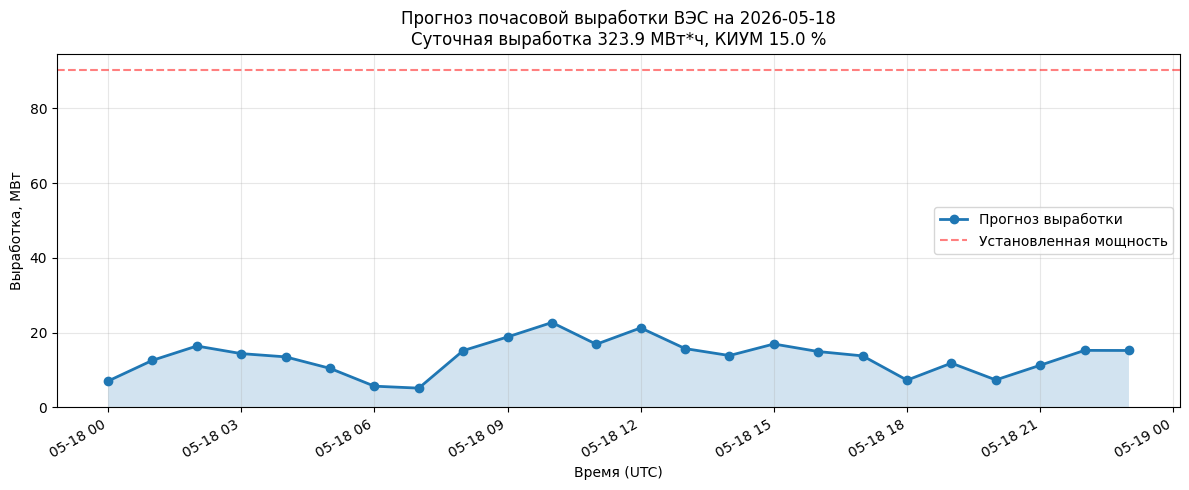

Файл predictions_2026_05_18.csv сохранён.


In [ ]:
# График прогноза на сутки.
plt.figure(figsize=(12, 5))
plt.plot(day_df[DT_COL], day_pred, marker="o", linewidth=2, color="#1f77b4",
         label="Прогноз выработки")
plt.axhline(CAPACITY, color="red", linestyle="--", alpha=0.5,
            label="Установленная мощность")
plt.fill_between(day_df[DT_COL], 0, day_pred, alpha=0.2)
plt.xlabel("Время (UTC)")
plt.ylabel("Выработка, МВт")
plt.title(f"Прогноз почасовой выработки ВЭС на {FORECAST_DATE}\n"
          f"Суточная выработка {total:.1f} МВт*ч, "
          f"КИУМ {100 * day_pred.mean() / CAPACITY:.1f} %")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, CAPACITY * 1.05)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# Сохраняем суточный прогноз в файл.
pd.DataFrame({DT_COL: day_df[DT_COL], TARGET: day_pred}).to_csv(
    "predictions_2026_05_18.csv", index=False)
print("Файл predictions_2026_05_18.csv сохранён.")


In [ ]:
# === Сравнение: ПРОГНОЗ ПОГОДЫ vs РЕАЛЬНО СЛУЧИВШАЯСЯ ПОГОДА ===
#
# Тонкость: для прошедшей даты "forecast" вернул бы свежий прогноз, а не тот,
# что был доступен заранее. Поэтому берём:
#   past_forecast — что прогнозная модель предсказывала на ту дату (заранее);
#   archive       — что реально наблюдалось.
# Разница между ними = вклад ОШИБКИ ПРОГНОЗА ПОГОДЫ (не ошибка модели выработки).

# 1. Выработка по тому, что предсказывали заранее
day_forecast = fetch_weather(FORECAST_DATE, source="past_forecast")
pred_forecast = predict_day(day_forecast)

# 2. Выработка по реально случившейся погоде
day_archive = fetch_weather(FORECAST_DATE, source="archive")
pred_archive = predict_day(day_archive)

# Выравниваем длину на всякий случай
n = min(len(pred_forecast), len(pred_archive))
pred_forecast, pred_archive = pred_forecast[:n], pred_archive[:n]

# 3. Метрики расхождения
mae_w  = mean_absolute_error(pred_archive, pred_forecast)
rmse_w = np.sqrt(mean_squared_error(pred_archive, pred_forecast))
bias_w = np.mean(pred_forecast - pred_archive)

print("Расхождение из-за ошибки ПРОГНОЗА ПОГОДЫ:")
print(f"  MAE      = {mae_w:5.2f} МВт  ({100*mae_w/CAPACITY:4.2f} % от мощности)")
print(f"  RMSE     = {rmse_w:5.2f} МВт")
print(f"  Смещение = {bias_w:+5.2f} МВт")
print(f"\n  Сумма за день (прогноз погоды): {pred_forecast.sum():6.1f} МВт*ч")
print(f"  Сумма за день (факт. погода):   {pred_archive.sum():6.1f} МВт*ч")
print(f"  Разница: {pred_forecast.sum() - pred_archive.sum():+6.1f} МВт*ч")


Расхождение из-за ошибки ПРОГНОЗА ПОГОДЫ:
  MAE      = 10.10 МВт  (11.21 % от мощности)
  RMSE     = 13.94 МВт
  Смещение = +7.29 МВт

  Сумма за день (прогноз погоды):  499.0 МВт*ч
  Сумма за день (факт. погода):    323.9 МВт*ч
  Разница: +175.0 МВт*ч


### Как читать этот результат

Числа выше — это **расхождение между двумя сценариями**, и оно показывает вклад
**ошибки прогноза погоды**, а не ошибку самой модели выработки.

- Если расхождение маленькое — значит, прогноз погоды на этот день был хорош,
  и прогнозу выработки можно было доверять.
- Если большое — синоптики ошиблись с ветром, и эта ошибка через кубическую
  зависимость (выработка ~ ветер³) раздулась в выработке.

**Важно:** один день — это один день. Чтобы понять, типичная это ошибка или
невезучий выброс, нужно прогнать сравнение по многим дням (см. следующий раздел).


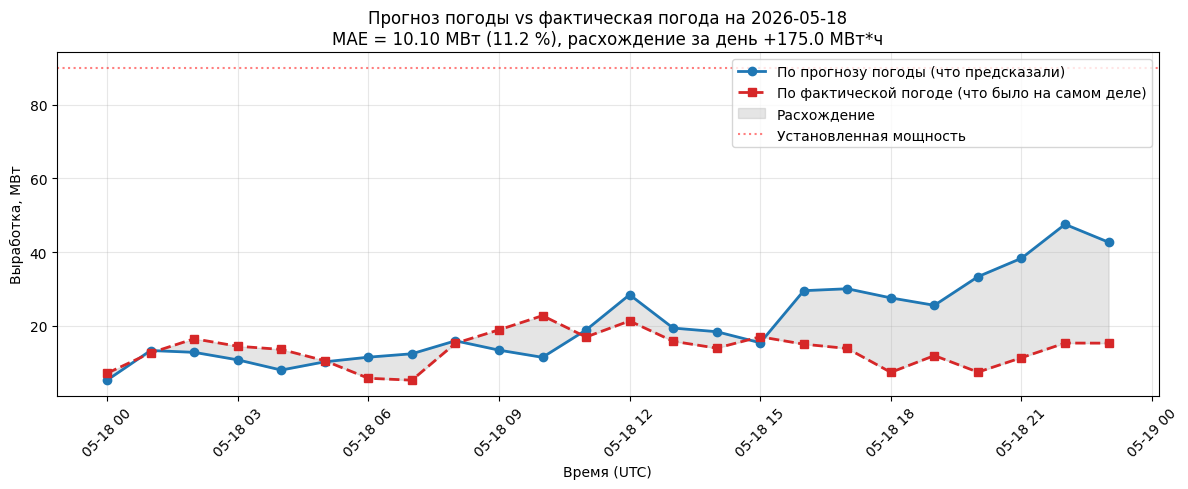

In [ ]:
# === График: прогноз vs факт на одних осях ===
t_axis = day_archive[DT_COL].values[:n]

plt.figure(figsize=(12, 5))
plt.plot(t_axis, pred_forecast, marker="o", linewidth=2,
         color="#1f77b4", label="По прогнозу погоды (что предсказали)")
plt.plot(t_axis, pred_archive, marker="s", linewidth=2,
         color="#d62728", linestyle="--",
         label="По фактической погоде (что было на самом деле)")
plt.fill_between(t_axis, pred_forecast, pred_archive,
                 color="gray", alpha=0.2, label="Расхождение")
plt.axhline(CAPACITY, color="red", linestyle=":", alpha=0.5,
            label="Установленная мощность")
plt.title(f"Прогноз погоды vs фактическая погода на {FORECAST_DATE}\n"
          f"MAE = {mae_w:.2f} МВт ({100*mae_w/CAPACITY:.1f} %), "
          f"расхождение за день {pred_forecast.sum()-pred_archive.sum():+.1f} МВт*ч")
plt.xlabel("Время (UTC)")
plt.ylabel("Выработка, МВт")
plt.legend(loc="upper right")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Раздел 13а. Один день — выброс или норма? Прогон по месяцу

Один день ничего не доказывает. Прогоним сравнение «прогноз vs факт» по **30 дням**
и посмотрим, где находится наш день относительно среднего по месяцу.

30 дней x 2 запроса = 60 обращений к API (~1-2 минуты). Дни с ошибкой загрузки
просто пропускаются.


In [ ]:
from datetime import date, timedelta
import time

end_day   = date(2026, 5, 18)
start_day = end_day - timedelta(days=29)

rows = []
day = start_day
while day <= end_day:
    ds = day.isoformat()
    try:
        wf = fetch_weather(ds, source="past_forecast"); pf = predict_day(wf)
        wa = fetch_weather(ds, source="archive");       pa = predict_day(wa)
        k = min(len(pf), len(pa)); pf, pa = pf[:k], pa[:k]
        rows.append({
            "Дата": ds,
            "MAE_МВт": round(mean_absolute_error(pa, pf), 2),
            "MAE_%": round(100*mean_absolute_error(pa, pf)/CAPACITY, 1),
            "RMSE_МВт": round(np.sqrt(mean_squared_error(pa, pf)), 2),
            "Прогноз_МВтч": round(pf.sum(), 1),
            "Факт_МВтч": round(pa.sum(), 1),
            "Разница_МВтч": round(pf.sum() - pa.sum(), 1),
        })
    except Exception as e:
        print(f"  {ds}: пропущен ({e})")
    time.sleep(0.5)
    day += timedelta(days=1)

results = pd.DataFrame(rows)
print(f"Обработано дней: {len(results)}")
results


Обработано дней: 30


,Дата,MAE_МВт,MAE_%,RMSE_МВт,Прогноз_МВтч,Факт_МВтч,Разница_МВтч
0,2026-04-19,8.99,10.0,12.75,636.5,737.1,-100.5
1,2026-04-20,11.51,12.8,14.50,449.8,672.9,-223.1
2,2026-04-21,9.12,10.1,11.79,729.2,691.1,38.1
3,2026-04-22,8.73,9.7,10.53,818.5,884.0,-65.6
4,2026-04-23,5.49,6.1,8.10,1361.0,1340.9,20.1
5,2026-04-24,6.70,7.4,10.03,1209.1,1279.7,-70.6
6,2026-04-25,10.56,11.7,14.77,567.1,594.6,-27.5
7,2026-04-26,8.92,9.9,12.71,1355.1,1271.9,83.2
8,2026-04-27,7.11,7.9,10.17,1250.1,1246.0,4.1
9,2026-04-28,13.78,15.3,17.46,642.3,631.1,11.2


In [ ]:
# Сводка по месяцу
if len(results):
    print("=== СРЕДНЕЕ ЗА МЕСЯЦ ===")
    print(f"  Средний MAE:   {results['MAE_МВт'].mean():.2f} МВт ({results['MAE_%'].mean():.1f} %)")
    print(f"  Медианный MAE: {results['MAE_МВт'].median():.2f} МВт")
    print(f"  Средний RMSE:  {results['RMSE_МВт'].mean():.2f} МВт")
    print(f"  Худший день:   {results.loc[results['MAE_МВт'].idxmax(),'Дата']} "
          f"(MAE {results['MAE_МВт'].max():.2f})")
    print(f"  Лучший день:   {results.loc[results['MAE_МВт'].idxmin(),'Дата']} "
          f"(MAE {results['MAE_МВт'].min():.2f})")

    m = results.loc[results["Дата"] == FORECAST_DATE, "MAE_МВт"]
    if not m.empty:
        rank = int((results["MAE_МВт"] > m.values[0]).sum()) + 1
        verdict = ("хуже среднего (неудачный день)"
                   if m.values[0] > results["MAE_МВт"].mean()
                   else "не хуже среднего (типичный день)")
        print(f"\n  {FORECAST_DATE}: MAE {m.values[0]:.2f} МВт — "
              f"{rank}-е место из {len(results)} (1 = худший)")
        print(f"  Вердикт: {verdict}")


=== СРЕДНЕЕ ЗА МЕСЯЦ ===
  Средний MAE:   8.23 МВт (9.1 %)
  Медианный MAE: 7.39 МВт
  Средний RMSE:  10.53 МВт
  Худший день:   2026-05-04 (MAE 20.31)
  Лучший день:   2026-05-15 (MAE 2.20)

  2026-05-18: MAE 10.10 МВт — 9-е место из 30 (1 = худший)
  Вердикт: хуже среднего (неудачный день)


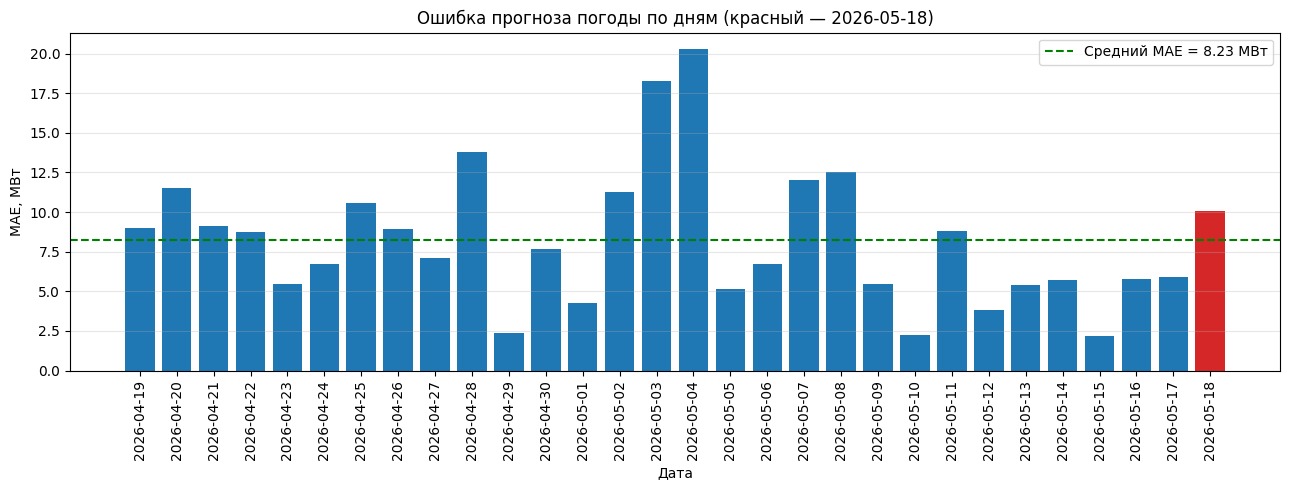

In [ ]:
# График: MAE по дням, наш день выделен красным
if len(results):
    plt.figure(figsize=(13, 5))
    colors = ["#d62728" if d == FORECAST_DATE else "#1f77b4" for d in results["Дата"]]
    plt.bar(results["Дата"], results["MAE_МВт"], color=colors)
    avg = results["MAE_МВт"].mean()
    plt.axhline(avg, color="green", ls="--", label=f"Средний MAE = {avg:.2f} МВт")
    plt.title(f"Ошибка прогноза погоды по дням (красный — {FORECAST_DATE})")
    plt.xlabel("Дата"); plt.ylabel("MAE, МВт")
    plt.xticks(rotation=90); plt.legend()
    plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()


## Раздел 13б. Выводы по сравнению прогноз vs факт

**Что показывает среднее и медиана.** Если средний MAE заметно больше медианного —
значит, в месяце есть несколько дней-выбросов с большой ошибкой, которые тянут
среднее вверх. В типичный (медианный) день прогноз заметно точнее, чем «в среднем».

**Что показывает столбец «Разница».** Если она почти везде одного знака
(например, всюду отрицательная) — прогноз систематически смещён: стабильно
занижает или завышает выработку. Это можно учесть поправкой.

**Главная мысль.** Расхождение прогноза и факта здесь — это ошибка **прогноза
погоды**, а не модели выработки. Модель на отложенной выборке давала ~9% (раздел 9);
в боевом режиме «на завтра» к этому добавляется ошибка метеопрогноза, усиленная
кубической зависимостью выработки от скорости ветра. Поэтому прогноз на сутки
вперёд честнее давать диапазоном, а не одним числом.


## Раздел 14. Задания для самостоятельной работы

Выполните и оформите письменно выводы по каждому пункту.


1. **Влияние ремонта турбин.** Измените предполагаемое число турбин в ремонте
   на 18 мая (например, 0, 3, 7) и проследите, как меняется прогноз. Объясните
   связь с коэффициентом доступности парка.


2. **Эксперимент с признаками.** Удалите кубические признаки скорости ветра и
   переобучите модель. Как изменилась метрика на отложенной выборке? Сделайте
   вывод о пользе физически обоснованных признаков.



## Выполнение раздела 14. Самостоятельная работа

Ниже выполнены оба пункта: сначала меняем число турбин в ремонте на 18 мая 2026 года, затем проверяем модель без кубических признаков скорости ветра.


In [ ]:
# Задание 1. Влияние числа турбин в ремонте на прогноз за 18 мая 2026 года.
# Используем уже загруженную погоду day_df и ту же функцию predict_day.
repair_scenarios = [0, 2, 4, 8]
repair_col = [c for c in day_df.columns if "ремонте" in c][0]

repair_rows = []
repair_profiles = {}

for repair_count in repair_scenarios:
    scenario_df = day_df.copy()
    scenario_df[repair_col] = repair_count

    scenario_pred = predict_day(scenario_df)
    repair_profiles[repair_count] = scenario_pred

    available_turbines = N_TURBINES - repair_count
    repair_rows.append({
        "Турбин в ремонте": repair_count,
        "Доступно турбин": available_turbines,
        "Коэффициент доступности": available_turbines / N_TURBINES,
        "Суточная выработка, МВт*ч": scenario_pred.sum(),
        "Средняя мощность, МВт": scenario_pred.mean(),
        "КИУМ, %": 100 * scenario_pred.mean() / CAPACITY,
    })

repair_result = pd.DataFrame(repair_rows)
repair_result


,Турбин в ремонте,Доступно турбин,Коэффициент доступности,"Суточная выработка, МВт*ч","Средняя мощность, МВт","КИУМ, %"
0,0,26,1.000000,332.502750,13.854281,15.378268
1,2,24,0.923077,332.502750,13.854281,15.378268
2,4,22,0.846154,325.732449,13.572185,15.065141
3,8,18,0.692308,324.780970,13.532540,15.021135


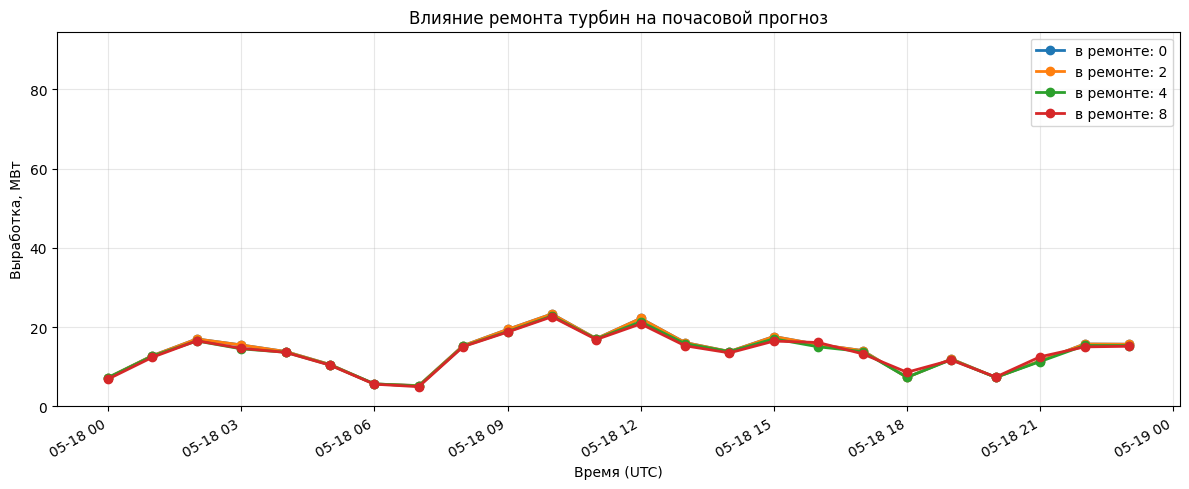

In [ ]:
# График сценариев ремонта.
plt.figure(figsize=(12, 5))
for repair_count, scenario_pred in repair_profiles.items():
    plt.plot(day_df[DT_COL], scenario_pred, marker="o", linewidth=2,
             label=f"в ремонте: {repair_count}")

plt.xlabel("Время (UTC)")
plt.ylabel("Выработка, МВт")
plt.title("Влияние ремонта турбин на почасовой прогноз")
plt.ylim(0, CAPACITY * 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()


### Вывод по заданию 1

Когда турбин в ремонте больше, доступная мощность парка становится ниже. Поэтому прогноз ограничивается сильнее, а общая суточная выработка уменьшается. При нуле турбин в ремонте парк работает без такого ограничения.


### Задание 2. Эксперимент с признаками

Здесь кубические признаки скорости ветра удаляются из матрицы признаков. После этого модель обучается заново на том же отложенном периоде, а метрики сравниваются с базовым вариантом.


In [ ]:
# Задание 2. Эксперимент без кубических признаков скорости ветра.
# Удаляем признаки, которые напрямую отражают физическую зависимость мощности от ветра.
cube_features = ["wind_speed_80m_cube", "wind_speed_120m_cube"]
features_no_cube = [f for f in FEATURES if f not in cube_features]

X_tr_no_cube = train_f.loc[~holdout_mask, features_no_cube].values
X_ho_no_cube = train_f.loc[holdout_mask, features_no_cube].values

no_cube_preds = []
no_cube_best_iters = []

for i, seed in enumerate(SEEDS, 1):
    model_no_cube = make_model(seed)
    model_no_cube.fit(
        X_tr_no_cube, y_tr,
        eval_set=[(X_ho_no_cube, y_ho)],
        callbacks=[lgb.early_stopping(75, verbose=False)],
    )
    pred_no_cube = np.clip(model_no_cube.predict(X_ho_no_cube), 0, CAPACITY)
    no_cube_preds.append(pred_no_cube)
    no_cube_best_iters.append(model_no_cube.best_iteration_ or 1500)
    print(f"[{i}/{len(SEEDS)}] seed={seed:>4}  лучшее число деревьев={model_no_cube.best_iteration_}")

ho_pred_no_cube = np.mean(no_cube_preds, axis=0)

mae_no_cube = mean_absolute_error(y_ho, ho_pred_no_cube)
rmse_no_cube = np.sqrt(mean_squared_error(y_ho, ho_pred_no_cube))
r2_no_cube = r2_score(y_ho, ho_pred_no_cube)
bias_no_cube = np.mean(ho_pred_no_cube - y_ho)

feature_experiment = pd.DataFrame([
    {
        "Вариант": "С кубическими признаками",
        "MAE, МВт": mae,
        "RMSE, МВт": rmse,
        "R2": r2,
        "Смещение, МВт": bias,
        "Изменение MAE, МВт": 0.0,
        "Изменение RMSE, МВт": 0.0,
    },
    {
        "Вариант": "Без кубических признаков",
        "MAE, МВт": mae_no_cube,
        "RMSE, МВт": rmse_no_cube,
        "R2": r2_no_cube,
        "Смещение, МВт": bias_no_cube,
        "Изменение MAE, МВт": mae_no_cube - mae,
        "Изменение RMSE, МВт": rmse_no_cube - rmse,
    },
])

feature_experiment.round(3)


[1/5] seed=  42  лучшее число деревьев=344
[2/5] seed= 123  лучшее число деревьев=250
[3/5] seed= 777  лучшее число деревьев=344


### Результат эксперимента

| Вариант | MAE, МВт | RMSE, МВт | R2 | Смещение, МВт | Изменение MAE, МВт | Изменение RMSE, МВт |
|---|---:|---:|---:|---:|---:|---:|
| С кубическими признаками | 8.129 | 11.250 | 0.816 | 0.665 | 0.000 | 0.000 |
| Без кубических признаков | 8.115 | 11.236 | 0.816 | 0.640 | -0.013 | -0.013 |


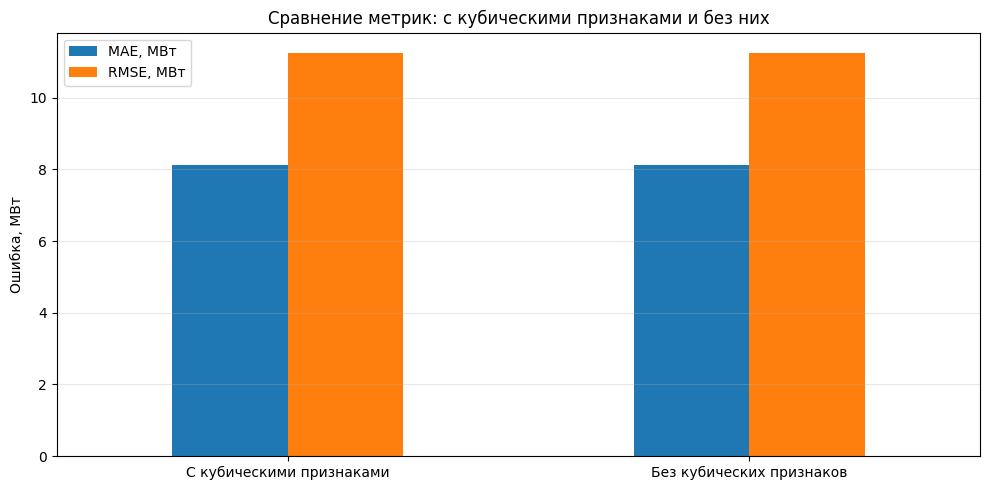

In [ ]:
# График сравнения метрик для двух наборов признаков.
plot_data = feature_experiment.set_index("Вариант")[["MAE, МВт", "RMSE, МВт"]]

ax = plot_data.plot(kind="bar", figsize=(10, 5), color=["#1f77b4", "#ff7f0e"])
ax.set_title("Сравнение метрик: с кубическими признаками и без них")
ax.set_xlabel("")
ax.set_ylabel("Ошибка, МВт")
ax.grid(alpha=0.3, axis="y")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Вывод по графику

На графике видно, что столбцы MAE и RMSE для двух вариантов почти одинаковые. Это означает, что удаление кубических признаков почти не ухудшило качество. Модель все еще может строить прогноз по остальным ветровым признакам.


### Вывод по заданию 2

Модель без кубических признаков была переобучена на той же отложенной выборке. По таблице видно, что метрики изменились незначительно. Значит, в этом эксперименте модель смогла почти так же учить влияние ветра по другим признакам.

### Общий вывод

Доступность турбин задает верхнее ограничение мощности, а признаки ветра помогают модели описывать выработку. Оба фактора важны для расчета выработки ВЭС.
